Data Loading

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/synthetic_user_financial_data.csv")
df.head()

,monthly_income,emi,monthly_expense,savings,risk_level
0,30795,15692,19968,-4865,Medium
1,15860,8597,9568,-2305,Medium
2,91820,19653,35483,36684,Low
3,69886,14398,47131,8357,Medium
4,21265,8622,9870,2773,Medium


Dataset Structure & Size

In [ ]:
df.shape
df.columns


Index(['monthly_income', 'emi', 'monthly_expense', 'savings', 'risk_level'], dtype='object')

Data Types & Missing Values

In [3]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   monthly_income   2000 non-null   int64 
 1   emi              2000 non-null   int64 
 2   monthly_expense  2000 non-null   int64 
 3   savings          2000 non-null   int64 
 4   risk_level       2000 non-null   object
dtypes: int64(4), object(1)
memory usage: 78.3+ KB


monthly_income     0
emi                0
monthly_expense    0
savings            0
risk_level         0
dtype: int64

Summary Statistics

In [4]:
df.describe()


,monthly_income,emi,monthly_expense,savings
count,2000.00000,2000.000000,2000.000000,2000.000000
mean,57095.92950,19913.057500,33949.680000,3233.192000
std,24708.18821,12292.078213,18075.717285,13869.898041
min,15055.00000,1607.000000,4853.000000,-40266.000000
25%,36558.50000,9785.750000,19231.750000,-4848.250000
50%,56859.50000,17212.500000,31277.500000,2594.000000
75%,78710.75000,27885.750000,45925.250000,10823.500000
max,99976.00000,58717.000000,87556.000000,55339.000000


Distribution of Financial Features

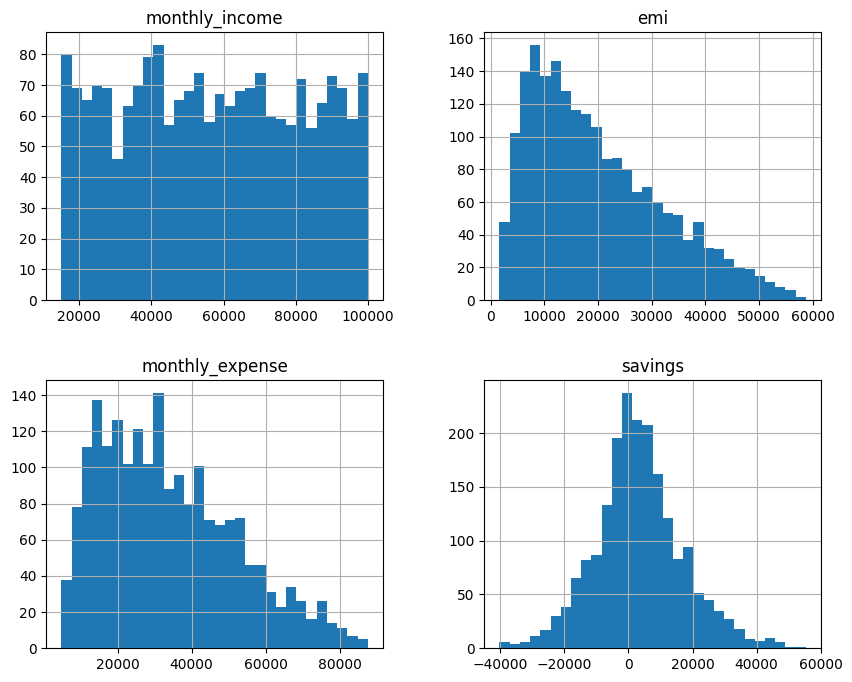

In [5]:
df[['monthly_income', 'emi', 'monthly_expense', 'savings']].hist(
    bins=30, figsize=(10,8)
)
plt.show()


Risk Level Distribution

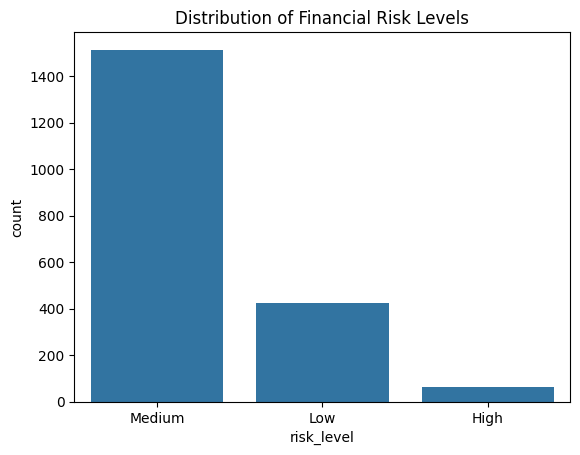

In [6]:
sns.countplot(x='risk_level', data=df)
plt.title("Distribution of Financial Risk Levels")
plt.show()


Derived Feature Analysis

In [7]:
df['emi_ratio'] = df['emi'] / df['monthly_income']
df['expense_ratio'] = df['monthly_expense'] / df['monthly_income']
df['savings_ratio'] = df['savings'] / df['monthly_income']

df[['emi_ratio', 'expense_ratio', 'savings_ratio']].describe()


,emi_ratio,expense_ratio,savings_ratio
count,2000.000000,2000.000000,2000.000000
mean,0.349553,0.594814,0.055633
std,0.144444,0.171514,0.224967
min,0.099996,0.300018,-0.484521
25%,0.225377,0.448157,-0.109022
50%,0.352499,0.589728,0.055613
75%,0.474337,0.742393,0.213156
max,0.599414,0.899682,0.577745


Risk Level vs Financial Ratios

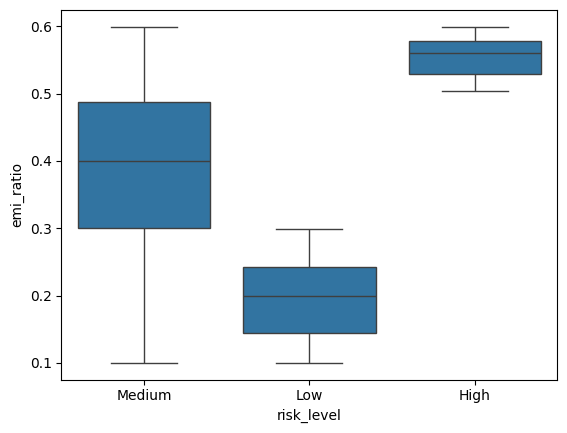

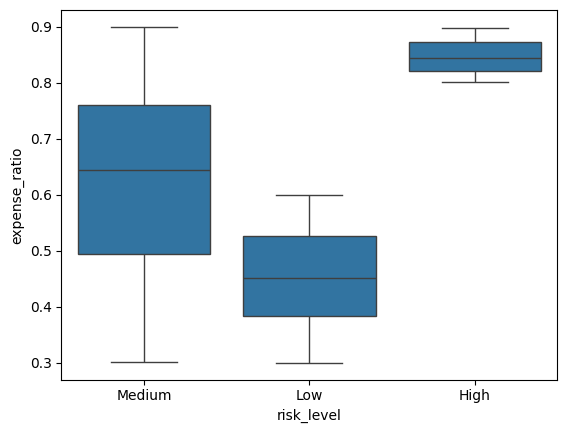

In [8]:
sns.boxplot(x='risk_level', y='emi_ratio', data=df)
plt.show()

sns.boxplot(x='risk_level', y='expense_ratio', data=df)
plt.show()


Savings Behavior Validation

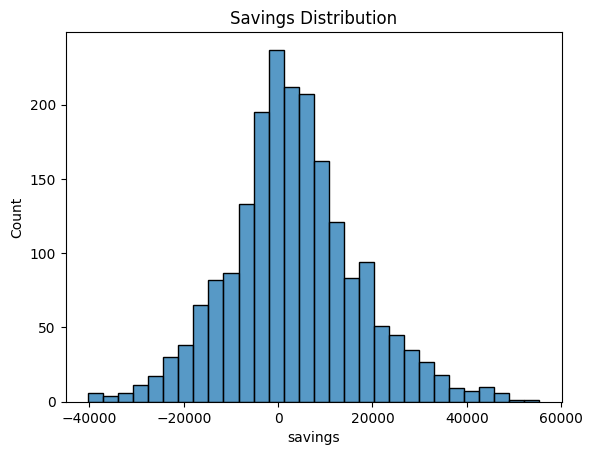

In [9]:
sns.histplot(df['savings'], bins=30)
plt.title("Savings Distribution")
plt.show()


CORRELATION ANALYSIS

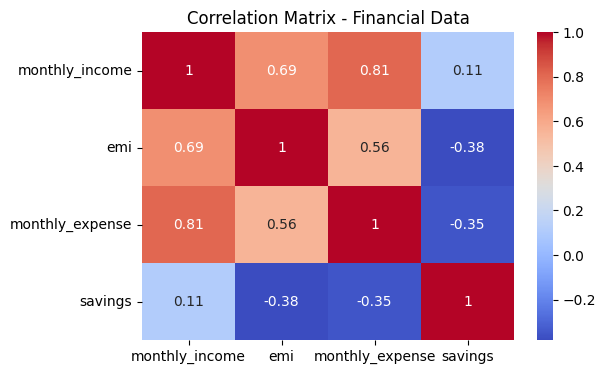

In [12]:
corr_matrix = df[['monthly_income','emi','monthly_expense','savings']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix - Financial Data")
plt.show()


OUTLIER DETECTION

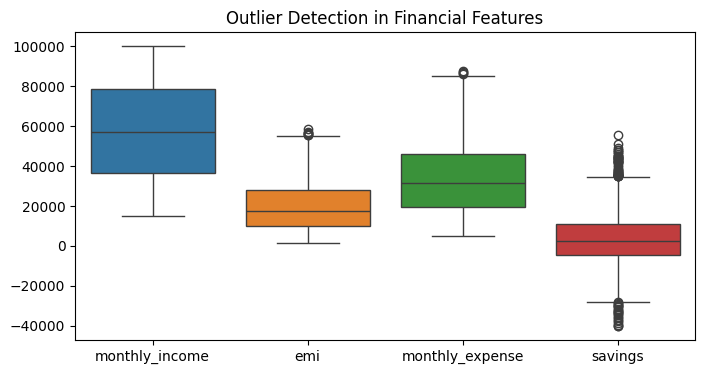

In [13]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df[['monthly_income','emi','monthly_expense','savings']])
plt.title("Outlier Detection in Financial Features")
plt.show()
